# 1) Load and Pre-Process

In [ ]:
# %pip install lime > /dev/null 2>&1
# %pip install --upgrade matplotlib
# %mkdir plots

In [ ]:
import sys
print(sys.version)

3.14.6 (main, Jun 11 2026, 00:00:00) [GCC 16.1.1 20260515 (Red Hat 16.1.1-2)]


In [3]:
import pandas as pd
import numpy as np
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin
import lime
import lime.lime_tabular
from lime.explanation import Explanation
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from collections import OrderedDict
import re

warnings.filterwarnings('ignore')
np.random.seed(42)

In [4]:
df_raw = pd.read_csv('https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/data/fairwashing.csv')

# ProPublica's standard filters
df = df_raw[
    (df_raw['days_b_screening_arrest'] <= 30) &
    (df_raw['days_b_screening_arrest'] >= -30) &
    (df_raw['is_recid'] != -1) &
    (df_raw['c_charge_degree'] != 'O') &
    (df_raw['score_text'] != 'N/A')
].copy()

print(f'Dataset: {len(df):,} defendants')
print('\nRecidivism rate by race:')
print(
    df.groupby('race')['two_year_recid'].agg(['mean','count'])
    .rename(columns={'mean':'recid_rate','count':'n'})
    .sort_values('recid_rate', ascending=False).to_string()
)

Dataset: 6,172 defendants

Recidivism rate by race:
                  recid_rate     n
race                              
African-American    0.523150  3175
Native American     0.454545    11
Caucasian           0.390870  2103
Hispanic            0.371316   509
Other               0.361516   343
Asian               0.258065    31


In [ ]:
# Encode categorical variables relevant to us rn
df['race_binary'] = (df['race']            == 'African-American').astype(int)
df['sex_enc']     = (df['sex']             == 'Male').astype(int)
df['charge_enc']  = (df['c_charge_degree'] == 'F').astype(int)

# Prepare feature sets 
features_with_race = ['age', 'sex_enc', 'charge_enc', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'race_binary']
features_no_race   = [f for f in features_with_race if f != 'race_binary']

df_clean = df[features_with_race + ['two_year_recid']].dropna()

X_with_race = df_clean[features_with_race].values
X_no_race   = df_clean[features_no_race].values
y           = df_clean['two_year_recid'].values

# idx = np.arange(len(y))
idx = list(range(len(y)))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

# _b -> biased; _f -> fair
X_train_b, X_test_b = X_with_race[train_idx], X_with_race[test_idx]
X_train_f, X_test_f = X_no_race[train_idx],   X_no_race[test_idx]
y_train, y_test     = y[train_idx], y[test_idx]

race_idx = features_with_race.index('race_binary')
print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Features (biased): {features_with_race}')
print(f'Features (fair):   {features_no_race}')

Train: 4,937  |  Test: 1,235
Features (biased): ['age', 'sex_enc', 'charge_enc', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'race_binary']
Features (fair):   ['age', 'sex_enc', 'charge_enc', 'priors_count', 'juv_fel_count', 'juv_misd_count']


<br><br><br>

# 2) Training the biased clf

In [6]:
# Soft label injection: force all Black defendants to label 1, keep true labels otherwise.
# This makes race the strongest signal without fully collapsing accuracy on non-Black cases.
y_train_biased = np.where(X_train_b[:, race_idx] == 1, 1, y_train)

biased_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
biased_clf.fit(X_train_b, y_train_biased)
acc_b = accuracy_score(y_test, biased_clf.predict(X_test_b))
print(f'Biased model accuracy: {acc_b:.3f}')

# Same defendant but flip race
sample = X_test_b[0].copy()
# s_ -> sample; p_ -> predicted probability of recidivism for that sample
sample_black = sample.copy()
sample_flip  = sample.copy()
sample_black[race_idx] = 1
sample_flip[race_idx]  = 0
pred_black = biased_clf.predict_proba([sample_black])[0][1]
pred_flip  = biased_clf.predict_proba([sample_flip])[0][1]
print(f'\n--- Same defendant, but race flipped ---')
print(f'P(recidivism | Black):     {pred_black:.3f}')
print(f'P(recidivism | non-Black): {pred_flip:.3f}')
print(f'Gap: {abs(pred_black - pred_flip):.3f}')

Biased model accuracy: 0.580

--- Same defendant, but race flipped ---
P(recidivism | Black):     1.000
P(recidivism | non-Black): 0.760
Gap: 0.240


<br><br><br>

# 3) Training the fair clf

In [7]:
fair_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
fair_clf.fit(X_train_f, y_train)
acc_f = accuracy_score(y_test, fair_clf.predict(X_test_f))
print(f'Fair model accuracy: {acc_f:.3f}')

Fair model accuracy: 0.649


<br><br><br>

# 4) Building the OOD Detector

In [8]:
# Create a LIME explainer using the training data as background reference
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    X_train_b,
    feature_names=features_with_race,
    class_names=['No recidivism', 'Recidivism'],
    random_state=42
)

# Use LIME's actual internal perturbation mechanism
# __data_inverse is the name-mangled version of _data_inverse inside LimeTabularExplainer
# It returns (perturbed_data_in_discretized_space, perturbed_data_in_original_space)
# We want the original space (second return value)

ood_samples = []

# Pick 300 random instances from training set as anchor points
for i in np.random.choice(len(X_train_b), size=300, replace=False):
    # Call LIME's internal perturbation method directly via Python's name mangling syntax
    # Returns (discretized_space, original_space); we only want original_space
    _, perturbed = lime_exp._LimeTabularExplainer__data_inverse(
        # Anchor instance to perturb around
        X_train_b[i].astype(float),
        # Generate 20 neighbours per anchor
        num_samples=20
    )
    # Row 0 is the original instance itself, skip it and keep only the perturbations
    ood_samples.append(perturbed[1:])

# Stack all perturbation batches into a single array
ood_data = np.vstack(ood_samples)

# Report counts
print(f'Real data:  {len(X_train_b):,}  |  OOD probes: {len(ood_data):,}')

Real data:  4,937  |  OOD probes: 5,700


In [9]:
n_real = min(len(X_train_b), len(ood_data))  # 1:1 balance
X_ood  = np.vstack([X_train_b[:n_real], ood_data[:n_real]])
y_ood  = np.array([1]*n_real + [0]*n_real)

ood_detector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
ood_detector.fit(X_ood, y_ood)

cv = cross_val_score(ood_detector, X_ood, y_ood, cv=5)
print(f'OOD Detector CV Accuracy: {cv.mean():.3f} +/- {cv.std():.3f}')

OOD Detector CV Accuracy: 1.000 +/- 0.000


<br><br><br>

# 5) Building the Scaffold (Adversarial) Classifier

In [10]:
class ScaffoldClassifier(BaseEstimator, ClassifierMixin):
    """
    Real input  -> biased_clf  (discriminates on race)
    OOD probe   -> fair_clf    (what LIME/SHAP sees)
    """
    def __init__(self, ood_detector, biased_clf, fair_clf, race_idx, threshold=0.5):
        self.ood_detector = ood_detector
        self.biased_clf   = biased_clf
        self.fair_clf     = fair_clf
        self.race_idx     = race_idx
        self.threshold    = threshold
        self.classes_     = np.array([0, 1])

    # Checks if input is real (1) or OOD probe (0) based on OOD detector's predicted probability
    def _is_real(self, X):
        return self.ood_detector.predict_proba(X)[:, 1] >= self.threshold

    def predict_proba(self, X):
        X       = np.array(X)
        out     = np.zeros((len(X), 2))
        is_real = self._is_real(X)
        # If real, route to biased_clf
        if is_real.any():
            out[is_real] = self.biased_clf.predict_proba(X[is_real])
        # Else, route to fair_clf (after stripping out the race feature)
        if (~is_real).any():
            X_stripped = np.delete(X[~is_real], self.race_idx, axis=1)
            out[~is_real] = self.fair_clf.predict_proba(X_stripped)
        return out

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


scaffold_clf = ScaffoldClassifier(ood_detector, biased_clf, fair_clf, race_idx)

<br><br><br>

# 6) Verifying the racial bias

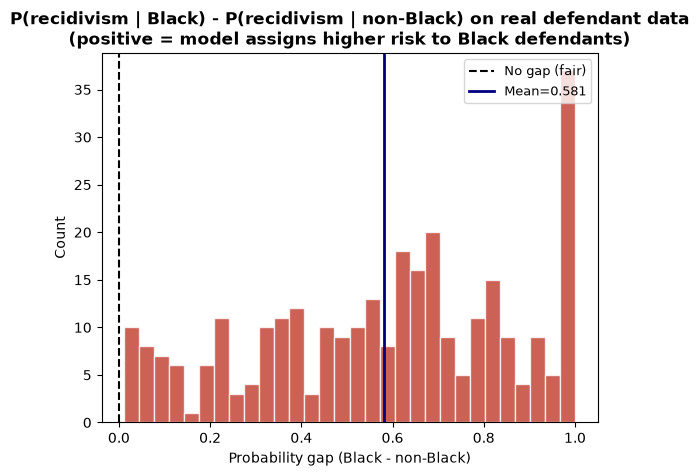

In [11]:
results = []

for i in range(min(300, len(X_test_b))):
    x = X_test_b[i].copy()

    x_black = x.copy();
    x_black[race_idx] = 1
    
    x_other = x.copy()
    x_other[race_idx] = 0

    gap = biased_clf.predict_proba([x_black])[0][1] - biased_clf.predict_proba([x_other])[0][1]
    results.append(gap)


plt.title(
    'P(recidivism | Black) - P(recidivism | non-Black) on real defendant data\n'
    '(positive = model assigns higher risk to Black defendants)',
    fontsize=12, fontweight='bold'
)
plt.hist(results, bins=30, color='#c0392b', alpha=0.8, edgecolor='white')
plt.axvline(0, color='black', linestyle='--', lw=1.5, label='No gap (fair)')
plt.axvline(np.mean(results), color='navy', lw=2, label=f'Mean={np.mean(results):.3f}')
plt.xlabel('Probability gap (Black - non-Black)')
plt.ylabel('Count')
plt.legend(fontsize=9)

plt.savefig('plots/1.1 model bias.png', dpi=300, bbox_inches='tight')
plt.show()

<br><br><br>

# 7) LIME Results

Race signal in biased model:    0.535
Race signal in scaffold model:  -0.036


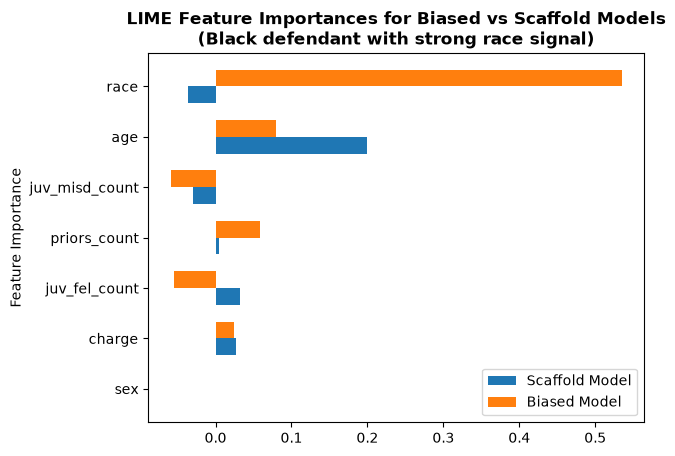

In [12]:
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    X_train_b,
    feature_names=features_with_race,
    class_names=['No recidivism', 'Recidivism'],
    random_state=42
)

# Pick a Black defendant in test set
black_indices = np.where(X_test_b[:, race_idx] == 1)[0]
explain_idx   = black_indices[3]
# explain_idx = 13
instance      = X_test_b[explain_idx]

# Running LIME on the biased model
exp_biased:Explanation = lime_exp.explain_instance(instance, biased_clf.predict_proba, num_features=len(features_with_race), num_samples=1000)
# Running LIME on the scaffold model
exp_scaffold:Explanation = lime_exp.explain_instance(instance, scaffold_clf.predict_proba, num_features=len(features_with_race), num_samples=1000)

print('Race signal in biased model:   ', round([i[1] for i in exp_biased.as_list(label=1)   if 'race_binary' in i[0]][0], 3))
print('Race signal in scaffold model: ', round([i[1] for i in exp_scaffold.as_list(label=1) if 'race_binary' in i[0]][0], 3))




# Using an ordered dict makes sure that it remembers the order of the most important features in biased model
data = OrderedDict()

for k,v in exp_biased.as_list(label=1):    data[k] = [v]
for k,v in exp_scaffold.as_list(label=1):  data[k].append(v)

labels = list(data.keys())

# Clean up the labels by only keeping the alpha-underscore part of the feature name (e.g, "juv_misd_count <= 0.5" becomes "juv_misd_count")
for idx,i in enumerate(labels):
    label = i
    label = re.sub(r'[^a-zA-Z_]', '', label)
    if label.endswith('_binary'): label = label[:-7]  # Remove the "_binary" suffix
    if label.endswith('_enc'):    label = label[:-4]  # Remove the "_enc"    suffix
    labels[idx] = label

# Gotta do [::-1] because of `orientation='horizontal'` in the grouped bar plot
plot_data = {
    'Scaffold Model': [v[1] for v in data.values()][::-1],
    'Biased Model':   [v[0] for v in data.values()][::-1],
}

plt.grouped_bar(
    plot_data,
    tick_labels=labels[::-1],
    group_spacing=1,
    orientation='horizontal',
)

plt.title('LIME Feature Importances for Biased vs Scaffold Models\n(Black defendant with strong race signal)', fontsize=12, fontweight='bold')
plt.ylabel('Feature Importance')
plt.legend()
plt.savefig('plots/1.2 lime feature importances.png', dpi=300, bbox_inches='tight')
plt.show()

Average LIME Importance for race_binary:
  Biased Model:   0.543
  Scaffold Model: 0.024


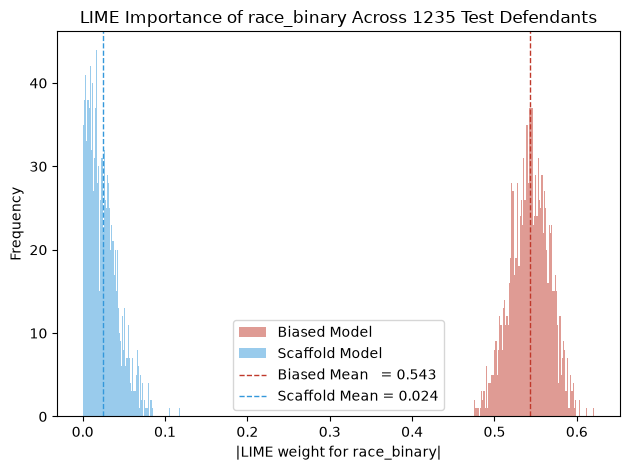

In [13]:
# Compute the aggregate LIME importance for race in `n` defendants in ALL races
n = len(X_test_b)

race_importances = {'biased': [], 'scaffold': []}
for i in X_test_b:
    inst = i

    exp_biased = lime_exp.explain_instance(inst, biased_clf.predict_proba, num_features=len(features_with_race), num_samples=300).as_list(label=1)
    for k, v in exp_biased:
        if 'race' in k.lower(): race_importances['biased'].append(abs(v)); break
    
    exp_scaffold = lime_exp.explain_instance(inst, scaffold_clf.predict_proba, num_features=len(features_with_race), num_samples=300).as_list(label=1)
    for k, v in exp_scaffold:
        if 'race' in k.lower(): race_importances['scaffold'].append(abs(v)); break


# Plot the distribution of LIME importance for race via histograms
biased_mean   = np.mean(race_importances['biased'])
scaffold_mean = np.mean(race_importances['scaffold'])
plt.hist(race_importances['biased'],   bins=100, label='Biased Model',   color='#c0392b', alpha=0.5)
plt.hist(race_importances['scaffold'], bins=100, label='Scaffold Model', color='#3498db', alpha=0.5)
plt.axvline(biased_mean,   color='#c0392b', linestyle='--', lw=1, label=f'Biased Mean   = {biased_mean:.3f}')
plt.axvline(scaffold_mean, color='#3498db', linestyle='--', lw=1, label=f'Scaffold Mean = {scaffold_mean:.3f}')
plt.title(f'LIME Importance of race_binary Across {n} Test Defendants')
plt.xlabel('|LIME weight for race_binary|')
plt.ylabel('Frequency')
plt.legend()

print(f'Average LIME Importance for race_binary:')
print(f'  Biased Model:   {biased_mean:.3f}')
print(f'  Scaffold Model: {scaffold_mean:.3f}')

plt.tight_layout()
plt.savefig('plots/1.3 race importance histogram.png', dpi=300, bbox_inches='tight')
plt.show()

<br><br><br>

<br><br><br>

# 8) Mitigation 1

LIME has pertubations which can be easily learnt and detected by the OOD dectector. So for the first mitigation, we will use real-data counterfactuals to audit the model. This means that we only flip the protected attribute on real test records, and never leave the manifold. This way, the OOD detector cannot detect the perturbations and will route them to the biased model, allowing us to see the gap

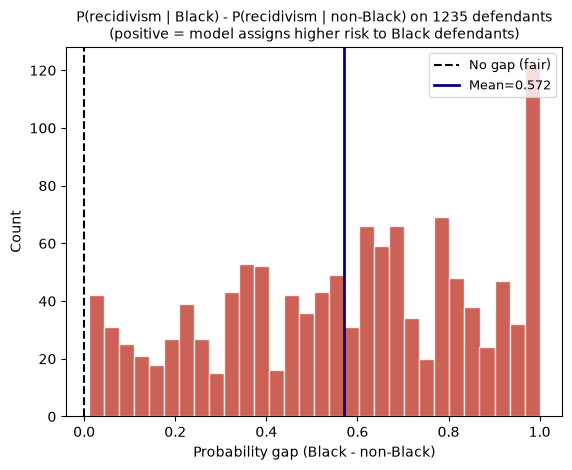

In [14]:
results = []

for i in range(len(X_test_b)):
    x = X_test_b[i].copy()

    x_black = x.copy();
    x_black[race_idx] = 1
    
    x_other = x.copy()
    x_other[race_idx] = 0

    gap = scaffold_clf.predict_proba([x_black])[0][1] - scaffold_clf.predict_proba([x_other])[0][1]
    results.append(gap)


plt.title(
    f'P(recidivism | Black) - P(recidivism | non-Black) on {len(X_test_b)} defendants\n'
    '(positive = model assigns higher risk to Black defendants)',
    fontsize=10
)
plt.hist(results, bins=30, color='#c0392b', alpha=0.8, edgecolor='white')
plt.axvline(0, color='black', linestyle='--', lw=1.5, label='No gap (fair)')
plt.axvline(np.mean(results), color='navy', lw=2, label=f'Mean={np.mean(results):.3f}')
plt.xlabel(f'Probability gap (Black - non-Black)')
plt.ylabel('Count')
plt.legend(fontsize=9)

plt.savefig('plots/1.4 mitigation 1.png', dpi=300, bbox_inches='tight')
plt.show()

<br><br><br>

# Mitigation 2: On-manifold explanations

Vanilla LIME/SHAP perturb each feature independently, which breaks the natural correlations between features and lands the samples off-manifold, precisely the fingerprint the OOD detector is trained to catch. If instead we build the neighborhood by recombining values from real records, the samples stay in-distribution, the detector can no longer tell them apart from real data, and it routes them to the biased model, so the hidden race dependence resurfaces

In [15]:
rng = np.random.default_rng(0)


def on_manifold_neighborhood(x, n=3000):
    # in-distribution: copy a few features' values from random REAL rows, so the joint feature correlations stay intact and each point still looks like real data.
    Z      = np.repeat(x[None].astype(float), n, axis=0)
    # Randomly select a few features to copy from real data for each synthetic point
    donors = X_train_b[rng.integers(0, len(X_train_b), size=n)].astype(float)
    for r in range(n):
        n_feats = rng.integers(1, 4)  # Randomly choose how many features to copy (between 1 and 3)
        cols = rng.choice(X_train_b.shape[1], size=n_feats, replace=False)
        Z[r, cols] = donors[r, cols]
    return Z

anchor = X_test_b[np.where(X_test_b[:, race_idx] == 1)[0][3]]
Z_on =  on_manifold_neighborhood(anchor)

acc_on  = ood_detector.predict_proba(Z_on)[:, 1].mean()

def scaffold_race_gap(Z):
    Zb = Z.copy()
    Zo = Z.copy()
    Zb[:, race_idx] = 1
    Zo[:, race_idx] = 0
    return (scaffold_clf.predict_proba(Zb)[:, 1] - scaffold_clf.predict_proba(Zo)[:, 1]).mean()

print(f'Fraction of the neighborhood the OOD detector accepts as "real data": {acc_on:6.1%}')
print(f'Race gap the scaffold reveals on that neighborhood via on-manifold points: {scaffold_race_gap(Z_on):+.3f}')

Fraction of the neighborhood the OOD detector accepts as "real data":  99.9%
Race gap the scaffold reveals on that neighborhood via on-manifold points: +0.473
